# Linear Model Training on Neurosoft Minipigs 2026

Minimal example: load a single session, extract fixed-length windows using
torch_brain's `SequentialFixedWindowSampler`, and train a logistic regression
on the **on_vs_off** binary classification task (intrasession split).

In [1]:
%matplotlib inline
# reload automatically
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import os
import h5py
from temporaldata import Data

from auditorydecoding.windowing import extract_windows
from auditorydecoding.plotting import plot_signal, plot_pca_variance, plot_covariance


In [3]:
WINDOW_LENGTH = 0.5  # seconds
FOLD_NUM = 0
SPLIT_TYPE = "intrasession-causal"
TASK_TYPE = "on_vs_off"
WHITEN = False

DATA_ROOT = "../data/processed/neurosoft_minipigs_2026"
RECORDING_ID = "sub-02_ses-01_task-AcousStim_acq-LH_desc-filtered"

## Load the data and preprocessing 

In [4]:
path = os.path.join(DATA_ROOT, RECORDING_ID + ".h5")

with h5py.File(path) as f:
    data = Data.from_hdf5(f, lazy=False)

CHANNEL_NAMES = data.channels.id

Here, we load all the splits and coalesce them to make them contiguous. We can do this because we are getting the causal splits.

We also filter the channels to only keep the ECoG channels.

In [5]:
# Get the intervals for each causal split and coalesce them to make them contiguous
train_intervals = data.splits.on_vs_off_causal_train.coalesce()
valid_intervals = data.splits.on_vs_off_causal_valid.coalesce()
test_intervals = data.splits.on_vs_off_causal_test.coalesce()

keep_channels = data.channels.type == "ecog"

channel_names = data.channels.id[keep_channels]

data_train = []
for interval in train_intervals:
    data_train.append(data.slice(interval[0], interval[1]).ecog.signal[:, keep_channels])

data_train = np.concatenate(data_train, axis=0)

data_valid = []
for interval in valid_intervals:
    data_valid.append(data.slice(interval[0], interval[1]).ecog.signal[:, keep_channels])

data_valid = np.concatenate(data_valid, axis=0)

data_test = []
for interval in test_intervals:
    data_test.append(data.slice(interval[0], interval[1]).ecog.signal[:, keep_channels])

data_test = np.concatenate(data_test, axis=0)

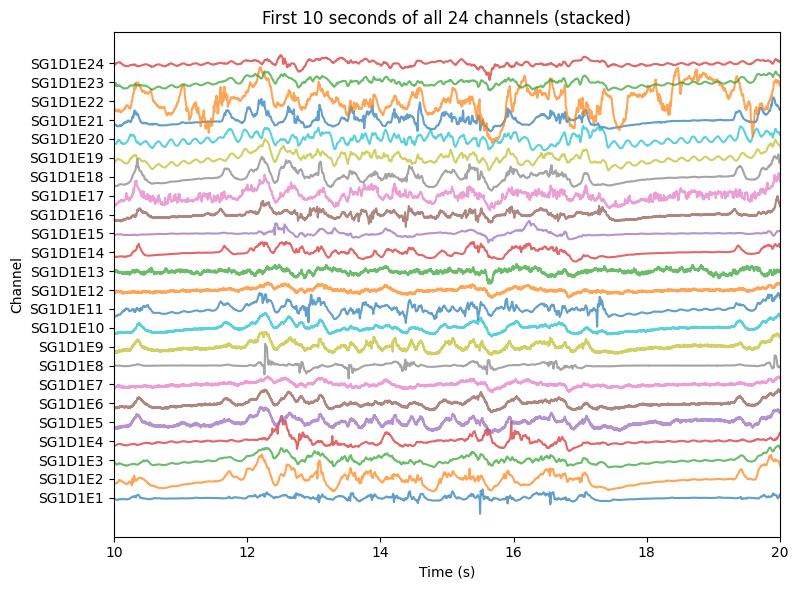

In [6]:
plot_signal(data_train, start=10, end=20, chann_names=channel_names)

## Some preprocessing

In [7]:
signal = data.ecog.signal[:, keep_channels]
timestamps = data.ecog.timestamps

#### Whitening the data

We get the training split and then use this to fit the whitening model.

In [8]:
train_intervals = data.splits.on_vs_off_causal_train.coalesce()
data_train = [data.slice(interval[0], interval[1]).ecog.signal[:, keep_channels] for interval in train_intervals]
data_train = np.concatenate(data_train, axis=0)

pca = PCA(whiten=False, n_components=2).fit(data_train)

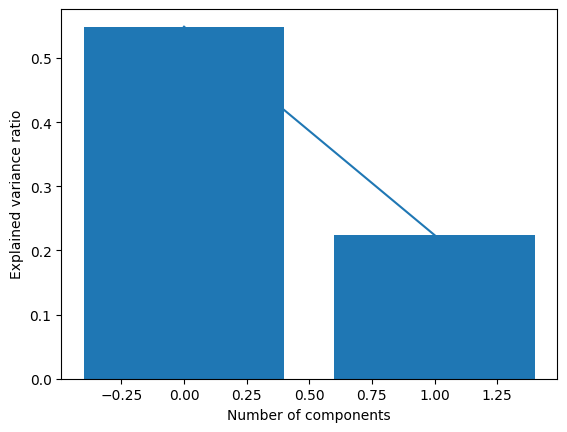

In [9]:
plot_pca_variance(pca)

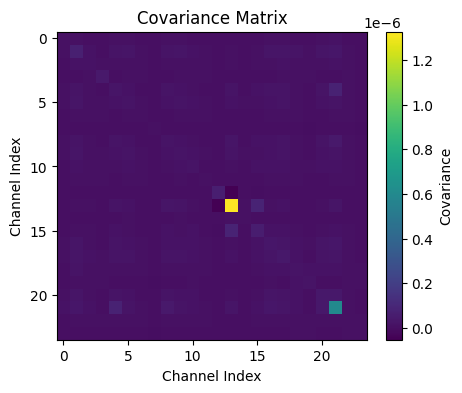

In [10]:
plot_covariance(np.cov(signal, rowvar=False))

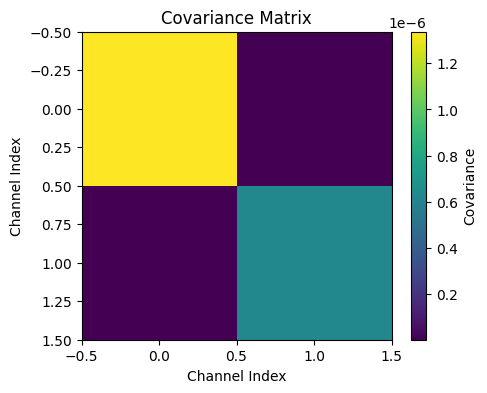

In [11]:
signal_whitened = pca.transform(signal)
plot_covariance(np.cov(signal_whitened, rowvar=False))

## Get windows and feature matrix

In [12]:
X_windows_train, y_windows_train = extract_windows(signal_whitened, timestamps, data.splits.on_vs_off_causal_train, WINDOW_LENGTH)
X_windows_valid, y_windows_valid = extract_windows(signal_whitened, timestamps, data.splits.on_vs_off_causal_valid, WINDOW_LENGTH)

le = LabelEncoder().fit(y_windows_train)
y_train_enc = le.transform(y_windows_train)
y_valid_enc = le.transform(y_windows_valid)

for name, X, y in [
    ("train", X_windows_train, y_windows_train),
    ("valid", X_windows_valid, y_windows_valid),
]:
    unique, counts = np.unique(y, return_counts=True)
    dist = ", ".join(f"{u}: {c}" for u, c in zip(unique, counts))
    print(f"{name:>5s}  X={X.shape}  y={y.shape}  classes={{ {dist} }}")

Extracting windows: 100%|██████████| 332/332 [00:01<00:00, 177.82it/s]

train  X=(2029, 1000, 2)  y=(2029,)  classes={ off: 1275, on: 754 }
valid  X=(332, 1000, 2)  y=(332,)  classes={ off: 209, on: 123 }


### Do the feature extraction here

In [13]:
from einops import rearrange

# X_stft_train = np.abs(np.fft.rfft(X_windows_train, axis=1))
# X_stft_valid = np.abs(np.fft.rfft(X_windows_valid, axis=1))

X_train = rearrange(X_windows_train, "s t c -> s (t c)")
X_valid = rearrange(X_windows_valid, "s t c -> s (t c)")

# X_train = X_windows_train.std(axis=1)
# X_valid = X_windows_valid.std(axis=1)

In [14]:
X_train.shape

(2029, 2000)

Feature matrix shapes:  train (2029, 2000)  valid (332, 2000)


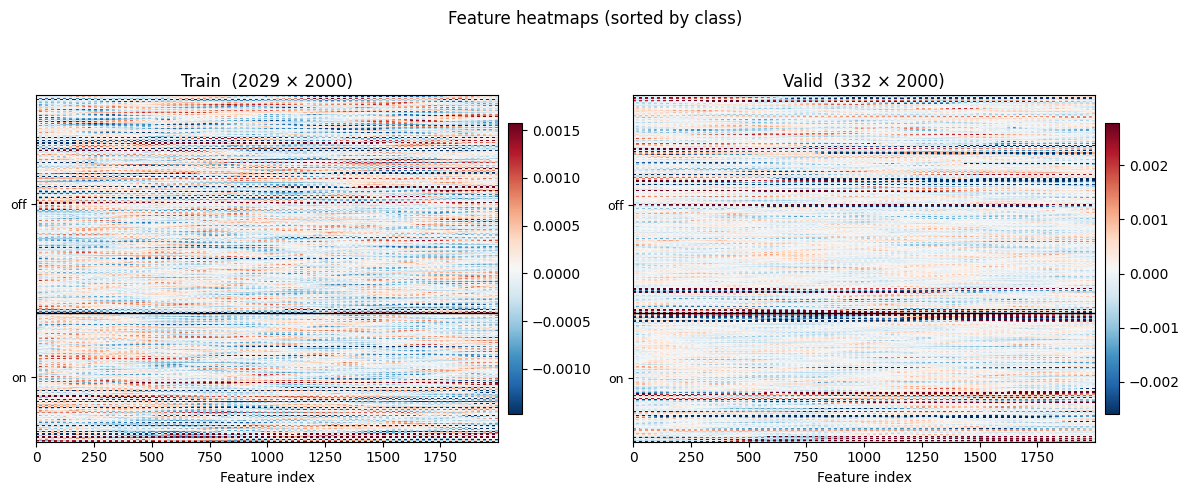

In [15]:
print(f"Feature matrix shapes:  train {X_train.shape}  valid {X_valid.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, X, y_enc, title in [
    (axes[0], X_train, y_train_enc, "Train"),
    (axes[1], X_valid, y_valid_enc, "Valid"),
]:
    order = np.argsort(y_enc)
    im = ax.imshow(
        X[order],
        aspect="auto",
        interpolation="none",
        cmap="RdBu_r",
        vmin=np.percentile(X, 2),
        vmax=np.percentile(X, 98),
    )

    boundaries = np.searchsorted(y_enc[order], np.arange(len(le.classes_)))
    for b in boundaries[1:]:
        ax.axhline(b - 0.5, color="k", linewidth=1)

    label_positions = [
        (boundaries[i] + (boundaries[i + 1] if i + 1 < len(boundaries) else len(y_enc))) / 2
        for i in range(len(boundaries))
    ]
    ax.set_yticks(label_positions)
    ax.set_yticklabels(le.classes_, fontsize=9)

    ax.set_xlabel("Feature index")
    ax.set_title(f"{title}  ({X.shape[0]} × {X.shape[1]})")
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)

fig.suptitle("Feature heatmaps (sorted by class)")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Balance the classes

In [16]:
BALANCE_CLASSES = False
if BALANCE_CLASSES:
    rng = np.random.default_rng(42)
    classes, counts = np.unique(y_train_enc, return_counts=True)
    min_count = counts.min()

    balanced_idx = np.concatenate([
        rng.choice(np.where(y_train_enc == c)[0], size=min_count, replace=False)
        for c in classes
    ])
    balanced_idx.sort()
    X_train, y_train, y_train_enc = (
        X_train[balanced_idx],
        y_train[balanced_idx],
        y_train_enc[balanced_idx],
    )

    for name, X, y in [
        ("train (balanced)", X_train, y_train),
        ("valid", X_valid, y_valid),
        ("test", X_test, y_test),
    ]:
        unique, cnt = np.unique(y, return_counts=True)
        dist = ", ".join(f"{u}: {c}" for u, c in zip(unique, cnt))
        print(f"{name:>20s}  X={X.shape}  classes={{ {dist} }}")

## Train the model

In [17]:
clf = LogisticRegression(max_iter=10000, class_weight="balanced")
clf.fit(X_train, y_train_enc)

val_acc = accuracy_score(y_valid_enc, clf.predict(X_valid))

print(f"Validation accuracy: {val_acc:.3f}")
print()
print(
    classification_report(
        y_valid_enc,
        clf.predict(X_valid),
        target_names=le.classes_,
    )
)

Validation accuracy: 0.630

              precision    recall  f1-score   support

         off       0.63      1.00      0.77       209
          on       0.00      0.00      0.00       123

    accuracy                           0.63       332
   macro avg       0.31      0.50      0.39       332
weighted avg       0.40      0.63      0.49       332



/home/mila/s/sobralm/auditorydecoding/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mila/s/sobralm/auditorydecoding/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mila/s/sobralm/auditorydecoding/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## Statistical Test: Is Performance Above Chance?

The test set is unbalanced, so raw accuracy alone is misleading. Two complementary tests are used:

- **Binomial test** (exact): tests whether raw accuracy exceeds the majority-class baseline (the accuracy a trivial "always predict majority" classifier would achieve).
- **Permutation test**: shuffles the test labels 10 000 times and recomputes **balanced accuracy** against the fixed model predictions each time. Balanced accuracy averages per-class recall, so its chance level is always 0.5 regardless of class proportions. The p-value is the fraction of permutations that matched or exceeded the observed balanced accuracy.

Validation set class counts  : off=209, on=123
Majority-class chance  : 0.630

Observed accuracy      : 0.630
Observed balanced acc  : 0.500

Binomial test  p-value : 0.5246  (H0: acc ≤ 0.630)
Permutation    p-value : 1  (n=10,000 permutations, balanced acc)


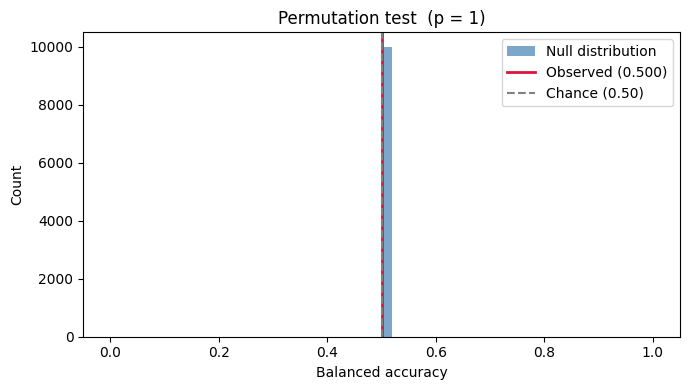

In [18]:
from scipy.stats import binomtest
from sklearn.metrics import balanced_accuracy_score

N_PERMUTATIONS = 10_000

y_pred_valid = clf.predict(X_valid)

# Majority-class proportion: the accuracy a trivial classifier achieves on this split
_, counts = np.unique(y_valid_enc, return_counts=True)
majority_chance = counts.max() / counts.sum()

n_correct = (y_pred_valid == y_valid_enc).sum()
n_total = len(y_valid_enc)
observed_acc = n_correct / n_total
observed_bal_acc = balanced_accuracy_score(y_valid_enc, y_pred_valid)

# --- Binomial test (raw accuracy vs. majority-class baseline) ---
binom_result = binomtest(n_correct, n_total, p=majority_chance, alternative="greater")

# --- Permutation test (balanced accuracy; chance = 0.5 by construction) ---
# Shuffling the true labels while keeping predictions fixed builds the null
# distribution under H0: labels are independent of neural activity.
rng = np.random.default_rng(0)
null_bal_accs = np.array([
    balanced_accuracy_score(rng.permutation(y_valid_enc), y_pred_valid)
    for _ in range(N_PERMUTATIONS)
])
permutation_pvalue = (null_bal_accs >= observed_bal_acc).mean()

class_counts_str = ", ".join(
    f"{le.classes_[c]}={counts[c]}" for c in range(len(le.classes_))
)
print(f"Validation set class counts  : {class_counts_str}")
print(f"Majority-class chance  : {majority_chance:.3f}")
print()
print(f"Observed accuracy      : {observed_acc:.3f}")
print(f"Observed balanced acc  : {observed_bal_acc:.3f}")
print()
print(f"Binomial test  p-value : {binom_result.pvalue:.4g}  (H0: acc ≤ {majority_chance:.3f})")
print(f"Permutation    p-value : {permutation_pvalue:.4g}  (n={N_PERMUTATIONS:,} permutations, balanced acc)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(null_bal_accs, bins=50, color="steelblue", alpha=0.7, label="Null distribution")
ax.axvline(observed_bal_acc, color="crimson", linewidth=2, label=f"Observed ({observed_bal_acc:.3f})")
ax.axvline(0.5, color="gray", linewidth=1.5, linestyle="--", label="Chance (0.50)")
ax.set_xlabel("Balanced accuracy")
ax.set_ylabel("Count")
ax.set_title(f"Permutation test  (p = {permutation_pvalue:.4g})")
ax.legend()
plt.tight_layout()
plt.show()

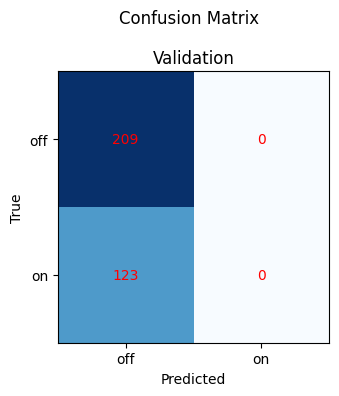

In [20]:
fig, ax = plt.subplots(figsize=(5, 4))

y_true = y_valid_enc
y_pred = clf.predict(X_valid)
cm = confusion_matrix(y_true, y_pred)
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(le.classes_)))
ax.set_yticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_)
ax.set_yticklabels(le.classes_)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Validation")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "red"  # "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color)

fig.suptitle("Confusion Matrix")
fig.tight_layout()
plt.show()